<a href="https://colab.research.google.com/github/bhatti0188/loan-approval/blob/main/Loan_Approval(internship_project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r'/content/Loan Approval.csv')
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
numerical_cols = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = pd.to_numeric(df["Dependents"])

In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Married",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)

In [ ]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.dtypes

,0
Loan_ID,object
Dependents,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Loan_Status,int64
Gender_Male,int64
Married_Yes,int64


In [ ]:
df = df.drop("Loan_ID", axis=1)

In [ ]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,1,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,0,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,1,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,1,1,0,0,0,0,1


In [ ]:
df.shape

(614, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Dependents               614 non-null    int64  
 1   ApplicantIncome          614 non-null    int64  
 2   CoapplicantIncome        614 non-null    float64
 3   LoanAmount               614 non-null    float64
 4   Loan_Amount_Term         614 non-null    float64
 5   Credit_History           614 non-null    float64
 6   Loan_Status              614 non-null    int64  
 7   Gender_Male              614 non-null    int64  
 8   Married_Yes              614 non-null    int64  
 9   Education_Not Graduate   614 non-null    int64  
 10  Self_Employed_Yes        614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    int64  
 12  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 62.5 KB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

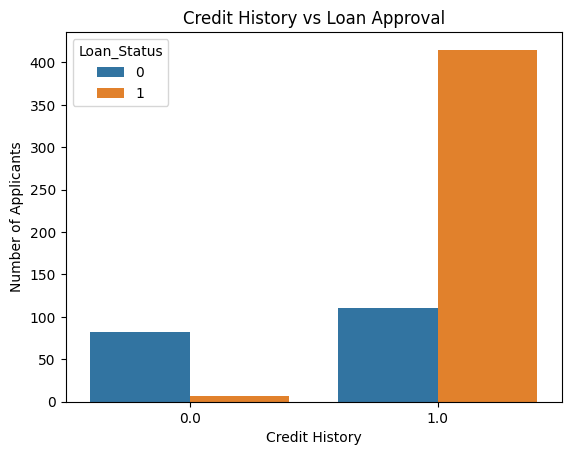

In [ ]:
sns.countplot(data=df, x="Credit_History", hue="Loan_Status")

plt.title("Credit History vs Loan Approval")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.show()

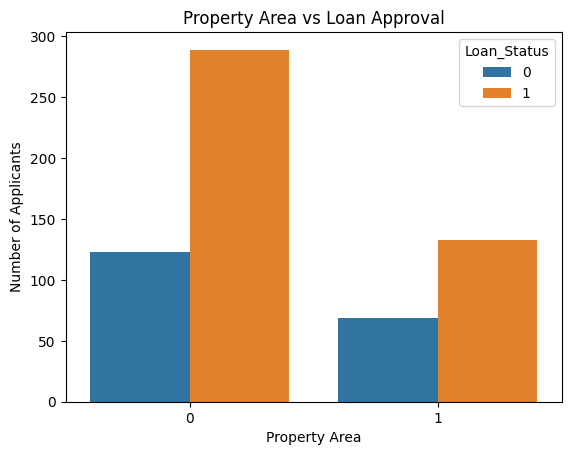

In [ ]:
sns.countplot(data=df, x="Property_Area_Urban", hue="Loan_Status")
plt.title("Property Area vs Loan Approval")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.show()

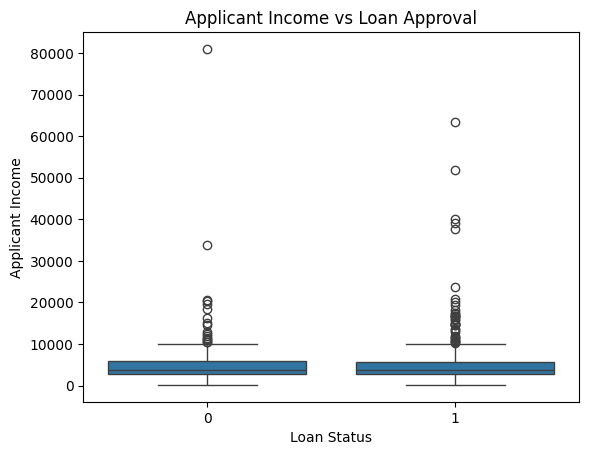

In [ ]:
sns.boxplot(data=df, x="Loan_Status", y="ApplicantIncome")

plt.title("Applicant Income vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

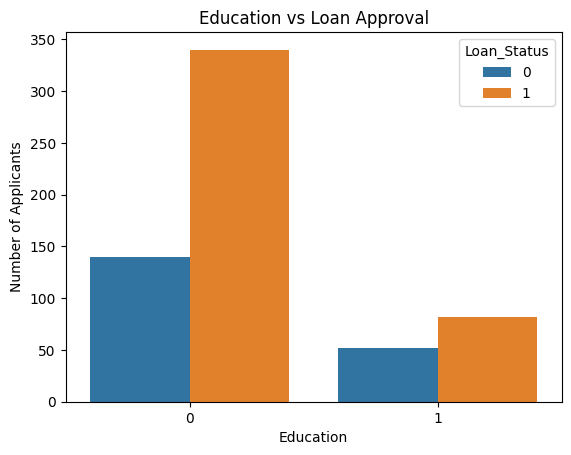

In [ ]:
sns.countplot(data=df, x="Education_Not Graduate", hue="Loan_Status")

plt.title("Education vs Loan Approval")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.show()

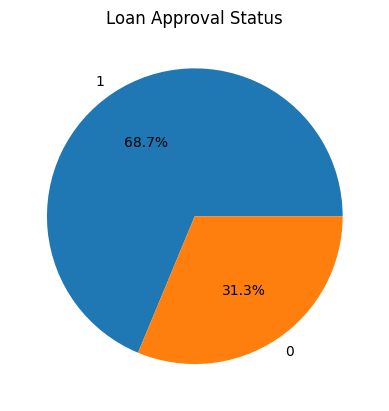

In [ ]:
df["Loan_Status"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.title("Loan Approval Status")
plt.ylabel("")
plt.show()

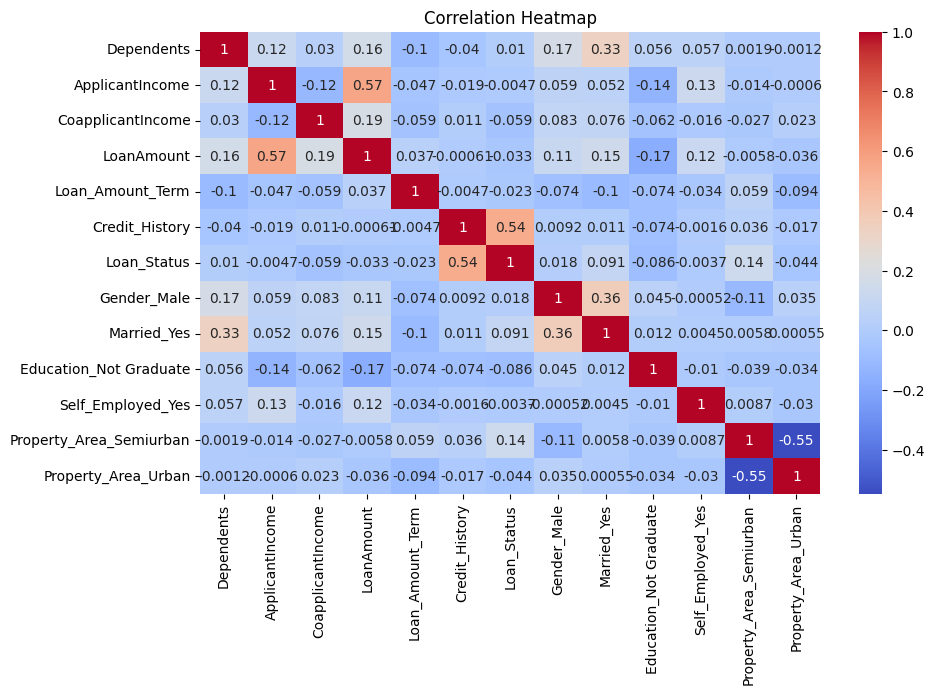

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 12)
Testing data: (123, 12)


In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
# build model
model = LogisticRegression(max_iter=1000)

In [ ]:
# Train model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Predict loan approval/rejection
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 0]


In [ ]:
#check probability for each class
y_prob = model.predict_proba(X_test)

print("Prediction Probabilities:")
print(y_prob)

Prediction Probabilities:
[[0.868431   0.131569  ]
 [0.12446193 0.87553807]
 [0.26823305 0.73176695]
 [0.21617804 0.78382196]
 [0.13429502 0.86570498]
 [0.21850124 0.78149876]
 [0.15540097 0.84459903]
 [0.18414729 0.81585271]
 [0.3101913  0.6898087 ]
 [0.30169209 0.69830791]
 [0.16234604 0.83765396]
 [0.21671724 0.78328276]
 [0.13805885 0.86194115]
 [0.25143358 0.74856642]
 [0.82419054 0.17580946]
 [0.81300047 0.18699953]
 [0.32511696 0.67488304]
 [0.76062696 0.23937304]
 [0.77619827 0.22380173]
 [0.29548823 0.70451177]
 [0.79956311 0.20043689]
 [0.41987488 0.58012512]
 [0.74924657 0.25075343]
 [0.16274057 0.83725943]
 [0.15829466 0.84170534]
 [0.19536433 0.80463567]
 [0.16994877 0.83005123]
 [0.26320942 0.73679058]
 [0.79870306 0.20129694]
 [0.23647974 0.76352026]
 [0.222666   0.777334  ]
 [0.14170635 0.85829365]
 [0.22851282 0.77148718]
 [0.23111486 0.76888514]
 [0.29459681 0.70540319]
 [0.20354536 0.79645464]
 [0.86786517 0.13213483]
 [0.08229106 0.91770894]
 [0.23380068 0.76619932]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_pred = model.predict(X_test)

# Probability for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1-Score: 0.9081081081081082
ROC-AUC: 0.8402476780185758

Confusion Matrix:
[[22 16]
 [ 1 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import pandas as pd

In [ ]:
def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_amount_term,
    credit_history,
    property_area
):

    # Create exactly the 12 columns used by the model
    input_data = pd.DataFrame([{
        "Dependents": dependents,
        "ApplicantIncome": applicant_income,
        "CoapplicantIncome": coapplicant_income,
        "LoanAmount": loan_amount,
        "Loan_Amount_Term": loan_amount_term,
        "Credit_History": credit_history,

        "Gender_Male": 1 if gender == "Male" else 0,
        "Married_Yes": 1 if married == "Yes" else 0,
        "Education_Not Graduate": 1 if education == "Not Graduate" else 0,
        "Self_Employed_Yes": 1 if self_employed == "Yes" else 0,
        "Property_Area_Semiurban": 1 if property_area == "Semiurban" else 0,
        "Property_Area_Urban": 1 if property_area == "Urban" else 0
    }])

    # VERY IMPORTANT:
    # Arrange columns in exactly the same order as model training
    input_data = input_data[model.feature_names_in_]

    # Prediction
    prediction = model.predict(input_data)[0]

    # Probability
    probability = model.predict_proba(input_data)[0][1] * 100

    if prediction == 1:
        result = "Loan Approved ✅"
    else:
        result = "Loan Rejected ❌"

    return f"{probability:.2f}%", result

In [ ]:
import gradio as gr

with gr.Blocks() as app:

    gr.Markdown("# 🏦 Loan Approval Prediction")
    gr.Markdown("Enter applicant information to predict loan approval.")

    gender = gr.Dropdown(
        ["Male", "Female"],
        label="Gender",
        value="Male"
    )

    married = gr.Dropdown(
        ["Yes", "No"],
        label="Married",
        value="Yes"
    )

    dependents = gr.Number(
        label="Dependents",
        value=0
    )

    education = gr.Dropdown(
        ["Graduate", "Not Graduate"],
        label="Education",
        value="Graduate"
    )

    self_employed = gr.Dropdown(
        ["Yes", "No"],
        label="Self Employed",
        value="No"
    )

    applicant_income = gr.Number(
        label="Applicant Income",
        value=5000
    )

    coapplicant_income = gr.Number(
        label="Coapplicant Income",
        value=0
    )

    loan_amount = gr.Number(
        label="Loan Amount",
        value=150
    )

    loan_amount_term = gr.Number(
        label="Loan Amount Term",
        value=360
    )

    credit_history = gr.Dropdown(
        [0, 1],
        label="Credit History",
        value=1
    )

    property_area = gr.Dropdown(
        ["Urban", "Semiurban", "Rural"],
        label="Property Area",
        value="Urban"
    )

    predict_button = gr.Button("Predict Loan")

    probability = gr.Textbox(
        label="Approval Probability"
    )

    prediction = gr.Textbox(
        label="Prediction"
    )

    predict_button.click(
        fn=predict_loan,
        inputs=[
            gender,
            married,
            dependents,
            education,
            self_employed,
            applicant_income,
            coapplicant_income,
            loan_amount,
            loan_amount_term,
            credit_history,
            property_area
        ],
        outputs=[
            probability,
            prediction
        ]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://abc753446c8c2d470c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
